In [ ]:
# # =============================================================================
# # NOTEBOOK 1: DATA UNDERSTANDING AND PREPROCESSING
# # =============================================================================

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import h5py
import json

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


In [4]:
# ---- Cell 2: Load the METR-LA Dataset ----
data_path = r'E:\urban-traffic-pattern-mining\data\metr-la.h5'
try:
    with h5py.File(data_path, 'r') as f:
        print("Keys in file:", list(f.keys()))

        data = f['df']['block0_values'][:]
        sensor_ids = f['df']['axis0'][:]
        timestamps = f['df']['axis1'][:]

    # Decode sensor IDs if bytes
    sensor_ids = [s.decode('utf-8') if isinstance(s, bytes) else s for s in sensor_ids]

    # Convert timestamps to DatetimeIndex
    timestamps = pd.to_datetime(timestamps)

    # Reconstruct DataFrame
    df = pd.DataFrame(data, index=timestamps, columns=sensor_ids)

    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"This means {df.shape[0]} time steps × {df.shape[1]} sensors")

except FileNotFoundError:
    print("File not found. Please download metr-la.h5 from:")
    print("https://github.com/liyaguang/DCRNN")
    print("and place it in the data/ folder.")


Keys in file: ['df']
Dataset loaded successfully!
Shape: (34272, 207)
This means 34272 time steps × 207 sensors


In [5]:
print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("LAST 5 ROWS OF THE DATASET")
print("=" * 60)
print(df.tail())

FIRST 5 ROWS OF THE DATASET
                        773869     767541     767542     717447     717446  \
2012-03-01 00:00:00  64.375000  67.625000  67.125000  61.500000  66.875000   
2012-03-01 00:05:00  62.666667  68.555556  65.444444  62.444444  64.444444   
2012-03-01 00:10:00  64.000000  63.750000  60.000000  59.000000  66.500000   
2012-03-01 00:15:00   0.000000   0.000000   0.000000   0.000000   0.000000   
2012-03-01 00:20:00   0.000000   0.000000   0.000000   0.000000   0.000000   

                        717445  773062  767620     737529     717816  ...  \
2012-03-01 00:00:00  68.750000  65.125  67.125  59.625000  62.750000  ...   
2012-03-01 00:05:00  68.111111  65.000  65.000  57.444444  63.333333  ...   
2012-03-01 00:10:00  66.250000  64.500  64.250  63.875000  65.375000  ...   
2012-03-01 00:15:00   0.000000   0.000   0.000   0.000000   0.000000  ...   
2012-03-01 00:20:00   0.000000   0.000   0.000   0.000000   0.000000  ...   

                        772167  769372  

In [6]:

# ---- Cell 4: Dataset Information ----
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"\nData type of values: {df.dtypes.unique()}")
print(f"\nIndex type: {type(df.index)}")
print(f"Index start: {df.index[0]}")
print(f"Index end: {df.index[-1]}")
print(f"Index frequency: {df.index.freq}")
print(f"\nTotal duration: {df.index[-1] - df.index[0]}")
print(f"Number of sensors: {df.shape[1]}")
print(f"Number of time steps: {df.shape[0]}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

total_expected = (df.index[-1] - df.index[0]).total_seconds() / 300 + 1
print(f"\nExpected time steps (5-min intervals): {int(total_expected)}")
print(f"Actual time steps: {df.shape[0]}")
print(f"Missing time steps: {int(total_expected) - df.shape[0]}")


DATASET INFORMATION

Data type of values: [dtype('float64')]

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index start: 2012-03-01 00:00:00
Index end: 2012-06-27 23:55:00
Index frequency: None

Total duration: 118 days 23:55:00
Number of sensors: 207
Number of time steps: 34272

Memory usage: 57.03 MB

Expected time steps (5-min intervals): 34272
Actual time steps: 34272
Missing time steps: 0


In [7]:
print("=" * 60)
print("STATISTICAL SUMMARY (ALL SENSORS)")
print("=" * 60)
stats_summary = df.describe()
print(stats_summary)

print(f"\nOverall mean speed: {df.values.mean():.2f} mph")
print(f"Overall median speed: {np.nanmedian(df.values):.2f} mph")
print(f"Overall std deviation: {df.values.std():.2f} mph")
print(f"Minimum speed observed: {df.values.min():.2f} mph")
print(f"Maximum speed observed: {df.values.max():.2f} mph")

STATISTICAL SUMMARY (ALL SENSORS)
             773869        767541        767542        717447        717446  \
count  34272.000000  34272.000000  34272.000000  34272.000000  34272.000000   
mean      54.631359     60.452789     60.726120     49.524287     46.079798   
std       22.619199     15.970239     18.313353     15.843261     19.350345   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%       60.364583     63.000000     65.444444     50.333333     34.666667   
50%       64.888889     65.000000     67.375000     53.875000     46.000000   
75%       66.875000     66.375000     68.444444     58.125000     64.500000   
max       70.000000     70.000000     70.000000     70.000000     70.000000   

             717445        773062        767620        737529        717816  \
count  34272.000000  34272.000000  34272.000000  34272.000000  34272.000000   
mean      50.952003     54.471684     57.255095     56.068044     52.871841   
std       16.6817

MISSING VALUE ANALYSIS

Total missing values: 0
Percentage missing: 0.0000%

Sensors with missing values: 0


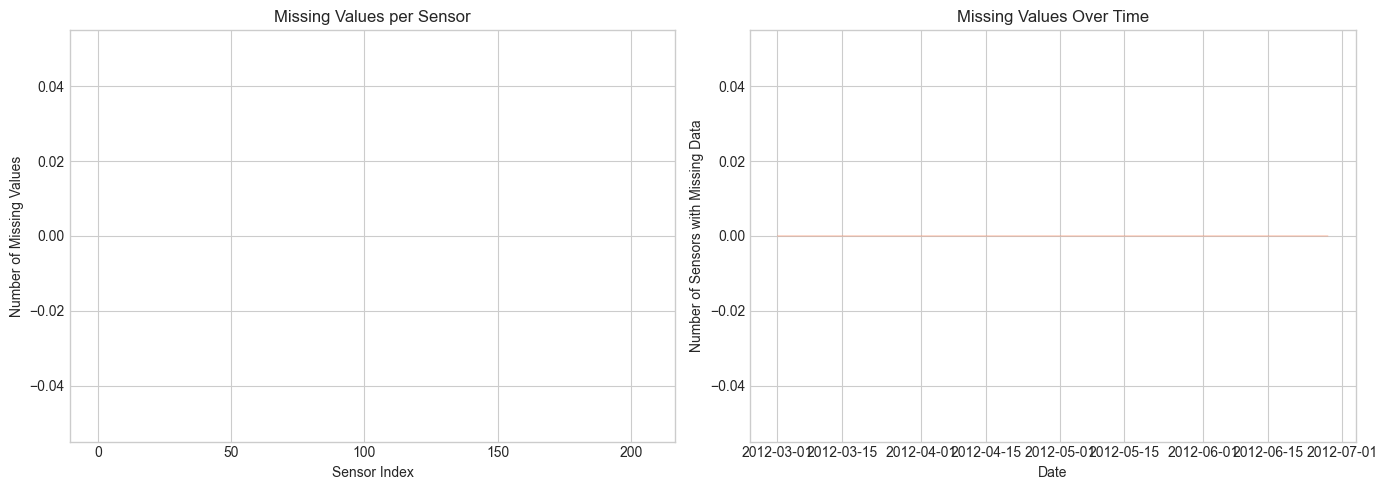

In [8]:

# ---- Cell 6: Missing Value Analysis ----
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_per_sensor = df.isnull().sum()
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage missing: {df.isnull().sum().sum() / df.size * 100:.4f}%")

print(f"\nSensors with missing values: {(missing_per_sensor > 0).sum()}")
if missing_per_sensor.max() > 0:
    print(f"Max missing values for a single sensor: {missing_per_sensor.max()}")
    print(f"Sensor with most missing: {missing_per_sensor.idxmax()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(missing_per_sensor)), missing_per_sensor.values,
            color='coral', alpha=0.7)
axes[0].set_xlabel('Sensor Index')
axes[0].set_ylabel('Number of Missing Values')
axes[0].set_title('Missing Values per Sensor')

missing_per_time = df.isnull().sum(axis=1)
axes[1].plot(df.index, missing_per_time, color='coral', alpha=0.7, linewidth=0.5)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Sensors with Missing Data')
axes[1].set_title('Missing Values Over Time')

plt.tight_layout()
plt.savefig('../data/missing_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Cell 7: Check for Zero and Abnormal Values ----


In [9]:
#CELL 7
print("=" * 60)
print("ZERO AND ABNORMAL VALUE ANALYSIS")
print("=" * 60)

zero_count = (df == 0).sum().sum()
print(f"Total zero values: {zero_count}")
print(f"Percentage zeros: {zero_count / df.size * 100:.4f}%")

very_low = (df < 5).sum().sum()
print(f"Values below 5 mph: {very_low}")
print(f"Percentage below 5 mph: {very_low / df.size * 100:.4f}%")

very_high = (df > 85).sum().sum()
print(f"Values above 85 mph: {very_high}")
print(f"Percentage above 85 mph: {very_high / df.size * 100:.4f}%")


ZERO AND ABNORMAL VALUE ANALYSIS
Total zero values: 575302
Percentage zeros: 8.1094%
Values below 5 mph: 578680
Percentage below 5 mph: 8.1570%
Values above 85 mph: 0
Percentage above 85 mph: 0.0000%


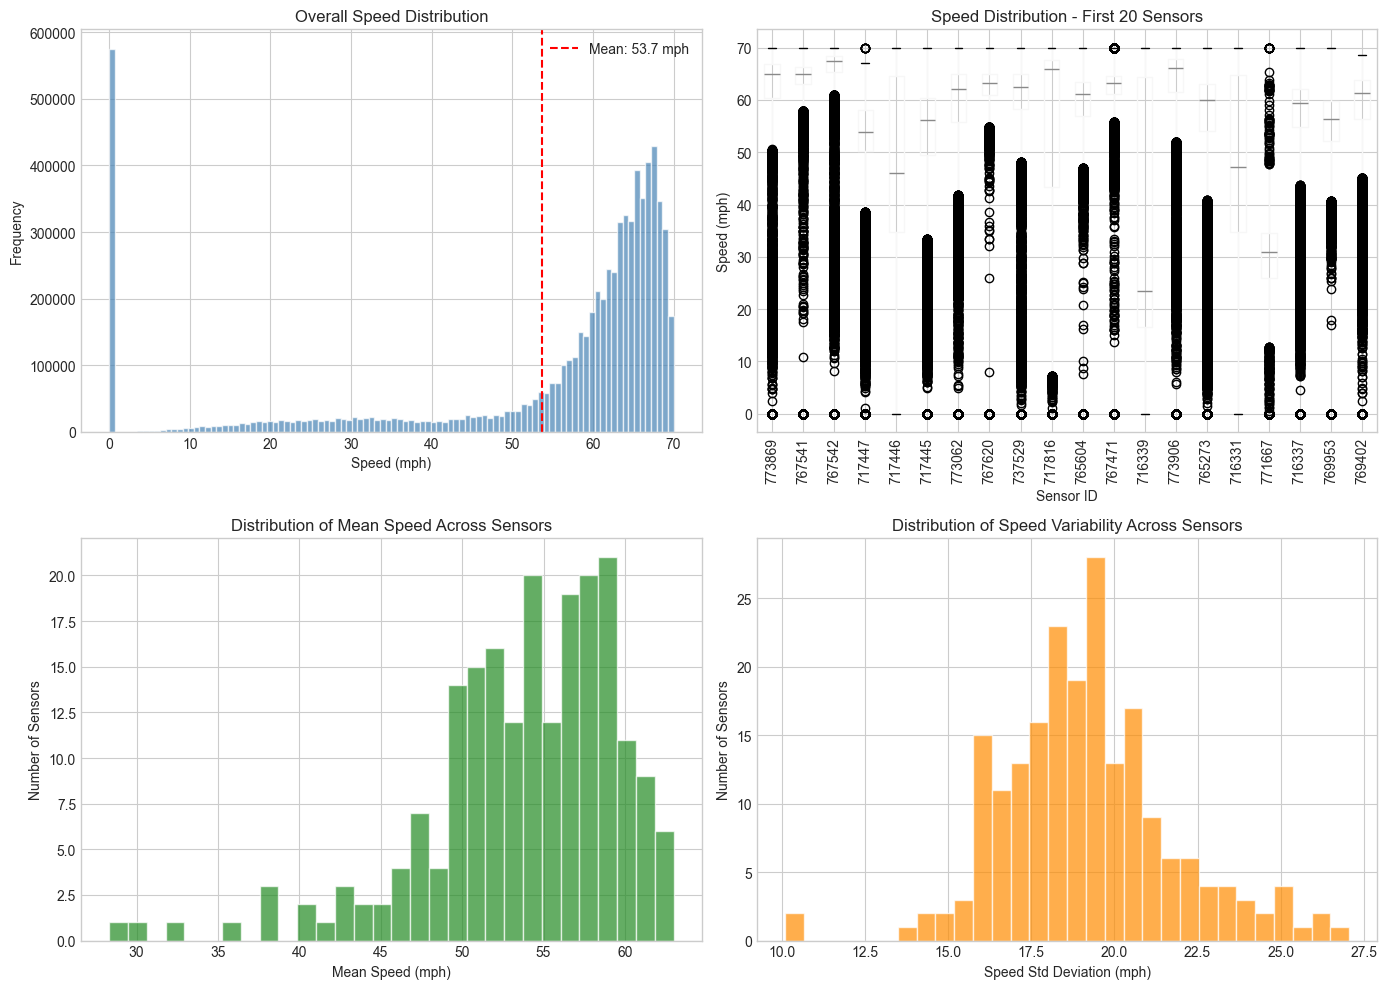

In [10]:
# ---- Cell 8: Data Distribution Visualization ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df.values.flatten(), bins=100, color='steelblue',
                alpha=0.7, edgecolor='white')
axes[0, 0].set_xlabel('Speed (mph)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Speed Distribution')
axes[0, 0].axvline(x=df.values.mean(), color='red', linestyle='--',
                    label=f'Mean: {df.values.mean():.1f} mph')
axes[0, 0].legend()

sample_sensors = df.columns[:20]
df[sample_sensors].boxplot(ax=axes[0, 1], rot=90)
axes[0, 1].set_xlabel('Sensor ID')
axes[0, 1].set_ylabel('Speed (mph)')
axes[0, 1].set_title('Speed Distribution - First 20 Sensors')

mean_speeds = df.mean()
axes[1, 0].hist(mean_speeds, bins=30, color='forestgreen',
                alpha=0.7, edgecolor='white')
axes[1, 0].set_xlabel('Mean Speed (mph)')
axes[1, 0].set_ylabel('Number of Sensors')
axes[1, 0].set_title('Distribution of Mean Speed Across Sensors')

std_speeds = df.std()
axes[1, 1].hist(std_speeds, bins=30, color='darkorange',
                alpha=0.7, edgecolor='white')
axes[1, 1].set_xlabel('Speed Std Deviation (mph)')
axes[1, 1].set_ylabel('Number of Sensors')
axes[1, 1].set_title('Distribution of Speed Variability Across Sensors')

plt.tight_layout()
plt.savefig('../data/speed_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

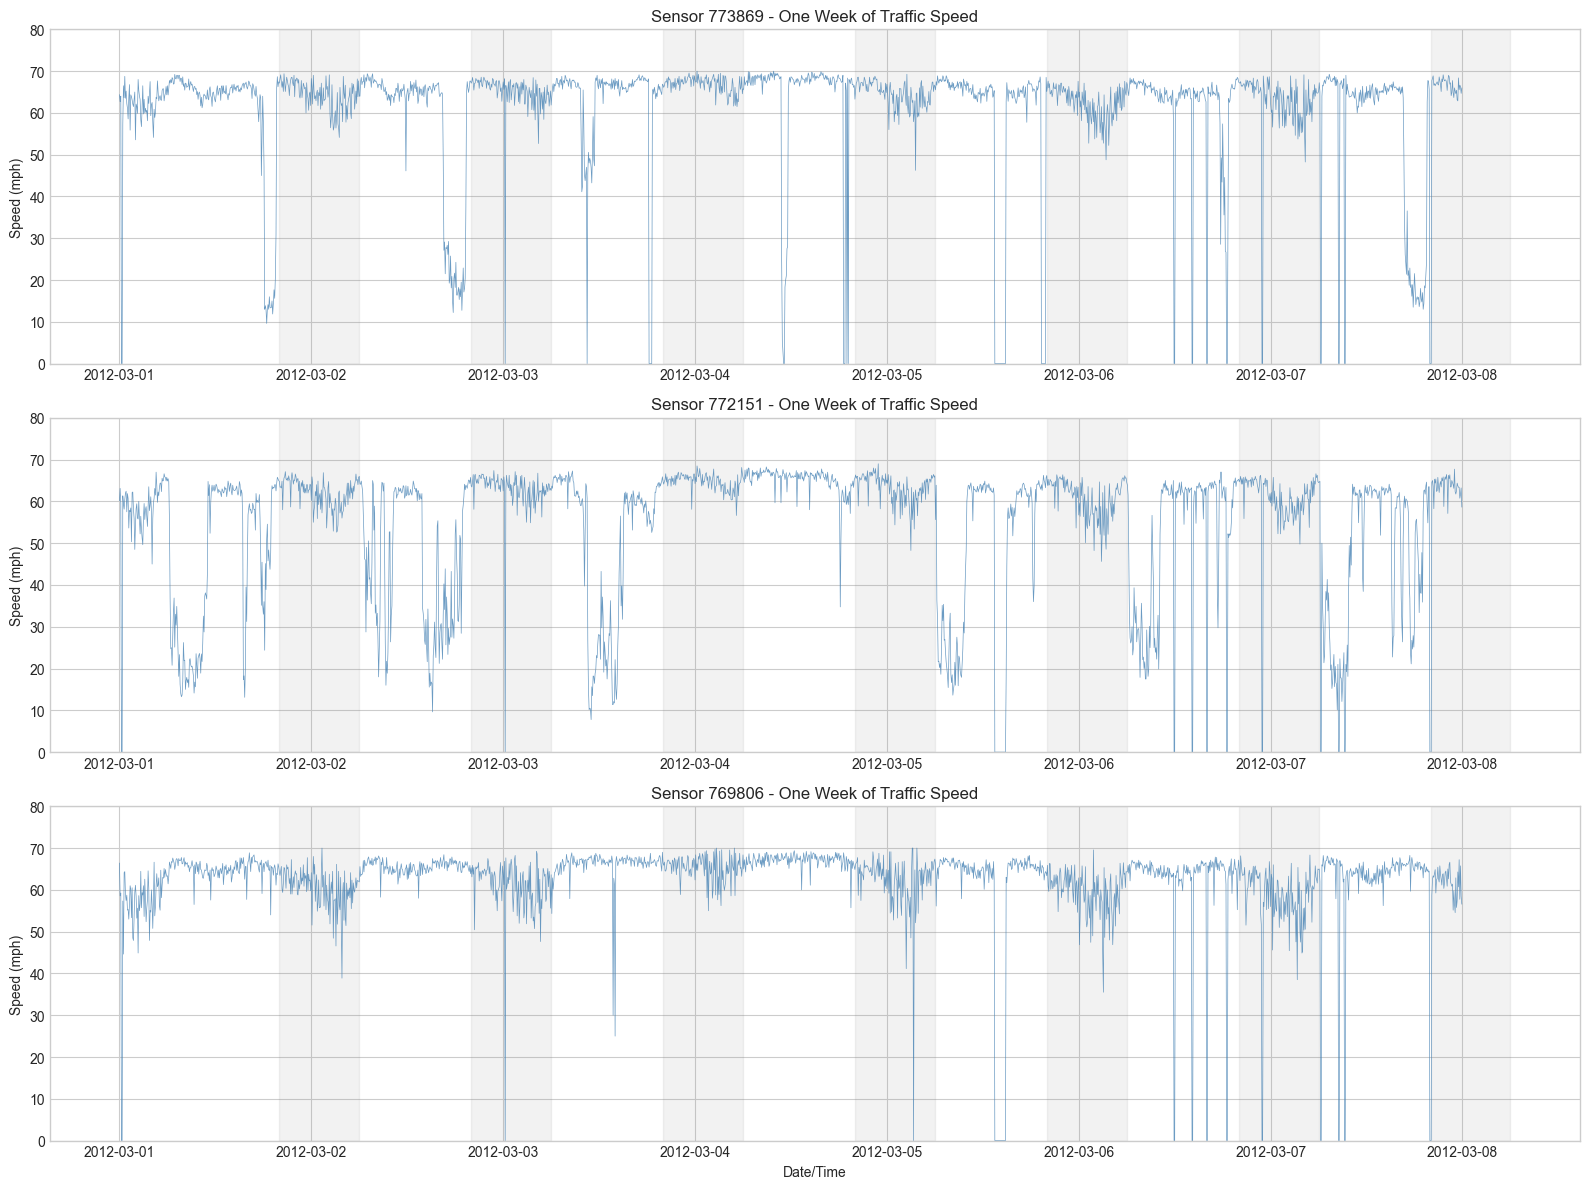

In [11]:
# ---- Cell 9: Temporal Pattern Preview ----
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

sample_sensors = [df.columns[0], df.columns[100], df.columns[200]]

for i, sensor in enumerate(sample_sensors):
    one_week = df[sensor].iloc[:2016]
    axes[i].plot(one_week.index, one_week.values, linewidth=0.5,
                 color='steelblue', alpha=0.8)
    axes[i].set_ylabel('Speed (mph)')
    axes[i].set_title(f'Sensor {sensor} - One Week of Traffic Speed')
    axes[i].set_ylim(0, 80)

    for day in range(7):
        night_start = one_week.index[0] + pd.Timedelta(days=day, hours=20)
        night_end = one_week.index[0] + pd.Timedelta(days=day+1, hours=6)
        axes[i].axvspan(night_start, night_end, alpha=0.1, color='gray')

axes[2].set_xlabel('Date/Time')
plt.tight_layout()
plt.savefig('../data/temporal_patterns_preview.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:

# ---- Cell 10: Data Cleaning and Preprocessing ----
print("=" * 60)
print("DATA CLEANING AND PREPROCESSING")
print("=" * 60)

df_clean = df.copy()
zero_replaced = (df_clean == 0).sum().sum()
df_clean = df_clean.replace(0, np.nan)
print(f"Step 1: Replaced {zero_replaced} zero values with NaN")

df_clean = df_clean.ffill(limit=6)
df_clean = df_clean.bfill(limit=6)
remaining_nan_1 = df_clean.isnull().sum().sum()
print(f"Step 2: After forward/backward fill, remaining NaN: {remaining_nan_1}")

if remaining_nan_1 > 0:
    df_clean = df_clean.fillna(df_clean.groupby(df_clean.index.time).transform('mean'))
    remaining_nan_2 = df_clean.isnull().sum().sum()
    print(f"Step 3: After time-of-day mean fill, remaining NaN: {remaining_nan_2}")

df_clean = df_clean.fillna(df_clean.mean())
remaining_nan_3 = df_clean.isnull().sum().sum()
print(f"Step 4: After column mean fill, remaining NaN: {remaining_nan_3}")

df_clean = df_clean.clip(lower=0, upper=85)
print(f"Step 5: Clipped values to range [0, 85] mph")

print(f"\nFinal cleaned dataset shape: {df_clean.shape}")
print(f"Final NaN count: {df_clean.isnull().sum().sum()}")


DATA CLEANING AND PREPROCESSING
Step 1: Replaced 575302 zero values with NaN
Step 2: After forward/backward fill, remaining NaN: 438265
Step 3: After time-of-day mean fill, remaining NaN: 0
Step 4: After column mean fill, remaining NaN: 0
Step 5: Clipped values to range [0, 85] mph

Final cleaned dataset shape: (34272, 207)
Final NaN count: 0


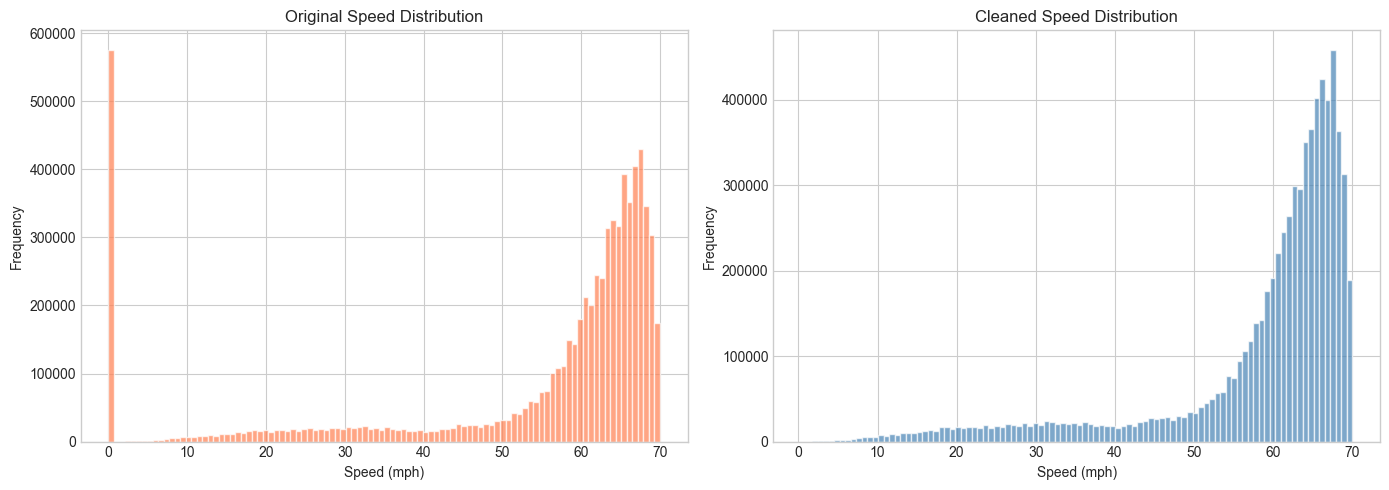

In [13]:

# ---- Cell 11: Verify Cleaned Data ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df.values.flatten(), bins=100, color='coral',
             alpha=0.7, edgecolor='white')
axes[0].set_title('Original Speed Distribution')
axes[0].set_xlabel('Speed (mph)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean.values.flatten(), bins=100, color='steelblue',
             alpha=0.7, edgecolor='white')
axes[1].set_title('Cleaned Speed Distribution')
axes[1].set_xlabel('Speed (mph)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/original_vs_cleaned.png', dpi=150, bbox_inches='tight')
plt.show()

ERROR: Could not find a version that satisfies the requirement pytables (from versions: none)
ERROR: No matching distribution found for pytables


In [16]:
!pip install tables

   ---------------------------------------- 0.0/6.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.5 MB ? eta -:--:--
   ----------- ---------------------------- 1.8/6.5 MB 6.3 MB/s eta 0:00:01
   ------------------------------------ --- 6.0/6.5 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 6.5/6.5 MB 11.8 MB/s  0:00:00
   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   ---------------------------------------- 3.1/3.1 MB 23.1 MB/s  0:00:00

   ---------------------------------------- 0/6 [py-cpuinfo]
   ------ --------------------------------- 1/6 [numexpr]
   ------------- -------------------------- 2/6 [ndindex]
   ------------- -------------------------- 2/6 [ndindex]
   ------------- -------------------------- 2/6 [ndindex]
   -------------------- ------------------- 3/6 [msgpack]
   -------------------------- ------------- 4/6 [blosc2]
   -----------

In [18]:
# ---- Cell 12: Save Cleaned Dataset ----
output_path = '../data/metr_la_cleaned.h5'
df_clean.to_hdf(output_path, key='df', mode='w')
print(f"Cleaned dataset saved to: {output_path}")
print(f"Shape: {df_clean.shape}")

metadata = {
    'num_sensors': df_clean.shape[1],
    'num_timesteps': df_clean.shape[0],
    'start_date': str(df_clean.index[0]),
    'end_date': str(df_clean.index[-1]),
    'frequency': '5min',
    'mean_speed': df_clean.values.mean(),
    'sensor_ids': list(df_clean.columns)
}

with open('../data/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("Metadata saved to: ../data/metadata.json")

print("\n" + "=" * 60)
print("NOTEBOOK 1 COMPLETE")
print("=" * 60)

Cleaned dataset saved to: ../data/metr_la_cleaned.h5
Shape: (34272, 207)
Metadata saved to: ../data/metadata.json

NOTEBOOK 1 COMPLETE
